# **Practical session 2**: Image Classification using CNNs

We have histopathological images for lung cancer detection. These images can correspond to adenocarcinomas (aca), squamous cell carcinomas (scc), or normal cells (n).

The dataset includes 5000 labeled images for each class. However, there are actually only 250 images per class, and the remaining 4750 are random rotations of the 250. Therefore, it will be unnecessary to process the entire dataset.
The images have 3 RGB colors and are 768x768 pixels.

The problem of this lab exercise is described here (https://www.kaggle.com/andrewmvd/lung-and-colon-cancer-histopathological-images).






**Q** What type of problem is this? (binary classification, multi-class classification, regression + supervised/non supervised/ reinforcement learning)

**Answer:** multi-class classification (aca scc or n), supervised (since images are labeled)



**I) Import Libraries**

As in the previous lab, import the following libraries:

*   tensorflow (tf)
*   numpy (np)
*   os *(Useful for moving folders)*
*   matplotlib.pyplot (plt) *(Useful for displaying images)*

Add the line
`from tensorflow.keras import layers` so you can avoid typing tf.keras.layers.dense each time and instead type layers.dense.





In [ ]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras import layers

Before proceeding further, you must check that the server where you are working with your COLAB session has a GPU. Go to Runtime > Change runtime type and ensure that GPU is selected as the hardware accelerator. Without a GPU, computation time may be high.

To know which GPU Colab has assigned you, type:
`!nvidia-smi -L`




In [ ]:
!nvidia-smi -L

GPU 0: NVIDIA L4 (UUID: GPU-d68ff959-f751-3e16-79a8-639fd94c8d79)


The more you use Colab for long sessions, the higher the load on their servers, and the more you request a high-performance GPU, the more likely it is that Colab will terminate your session and stop providing you with a GPU for a while. In that case, you will need to use a second Google account to complete the assignment.

It is essential to release the server from the session when you are no longer using it. To do this, go to Runtime > Manage sessions.



---
**II) Importing the Dataset**


 Download all the images to your virtual COLAB machine by writing: `!wget https://utsb-cloud.univ-catholille.fr/s/7nCmmNpCZxFBkoH/download/lung_image_sets_800.zip`
Then type `!unzip "lung_image_sets_800.zip" -d dataset` to unzip them
*   ! is used to execute a Linux command (not Python)
*   -d dataset specifies the destination folder




In [ ]:
!wget https://utsb-cloud.univ-catholille.fr/s/7nCmmNpCZxFBkoH/download/lung_image_sets_800.zip

--2026-01-26 12:48:52--  https://utsb-cloud.univ-catholille.fr/s/7nCmmNpCZxFBkoH/download/lung_image_sets_800.zip
Resolving utsb-cloud.univ-catholille.fr (utsb-cloud.univ-catholille.fr)... 195.220.78.103
Connecting to utsb-cloud.univ-catholille.fr (utsb-cloud.univ-catholille.fr)|195.220.78.103|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://utsb-cloud.univ-catholille.fr/public.php/dav/files/7nCmmNpCZxFBkoH/?accept=zip [following]
--2026-01-26 12:48:53--  https://utsb-cloud.univ-catholille.fr/public.php/dav/files/7nCmmNpCZxFBkoH/?accept=zip
Reusing existing connection to utsb-cloud.univ-catholille.fr:443.
HTTP request sent, awaiting response... 200 OK
Length: 148550717 (142M) [application/zip]
Saving to: ‘lung_image_sets_800.zip’

lung_image_sets_800 100%[===================>] 141.67M   894KB/s    in 2m 40s  

2026-01-26 12:51:33 (906 KB/s) - ‘lung_image_sets_800.zip’ saved [148550717/148550717]



In [ ]:
!unzip "lung_image_sets_800.zip" -d dataset

Archive:  lung_image_sets_800.zip
replace dataset/lung_image_sets/lung_aca/lungaca1.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

**III) Organizing folders for train/validation/test split**

The dataset contains 5,000 images per class. However, there were actually only 250 original images per class; the remaining 4,750 are random data augmentations (rotations, zooms, translations) of those 250. There is no information regarding the original image: it is not easily possible to determine whether two images originated from the same source image. We must split our database into training, validation, and test sets.

**Q.** What grave error did the dataset creators commit?

**Answer**: Since we do not know the original image a same patient can be simultaneously in the train validation and test dataset. We will have an overfitted model with a huge evaluation bias since the val and test data are almost the same as the training but the performance will be very different if true new unseen data is given.

Since there is no other way around it, we will ignore this error. While it won't hinder the pedagogical goals of this exercise, you must keep in mind that the resulting model would be unusable in practice due to overfitting, and the evaluation we perform will suffer from a significant assessment bias.

For each class, we will randomly select 200 samples for the training set, 100 for the validation set, and 500 for the test set.

*Note: Normally, we would apply a 60%/20%/20% split on the 250 original individuals. However, due to the flaw in this dataset, we are using a different 200/100/500 distribution. This ensures that, statistically, we have roughly 150 distinct images in the training set and 50 "unseen" images in the validation and test sets, thereby limiting overfitting.*

To perform this split, the simplest method is to distribute the three datasets into three different folders: train/, val/, and test/. Inside each of these folders, there must be three sub-folders—aca, n, and scc—containing the images for each of these three respective classes.

The code is provided below:

In [ ]:
index=np.arange(800)+1 # 0,2,...,4999
rng = np.random.default_rng(42)
rng.shuffle(index) # shuffle randomly

classes=['aca', 'n', 'scc']
datasets=['train','val','test']
indexlim=[0,200,300,800] # For each class, indices 0 to 200 will go to the training set, 200 to 300 to validation, and 300 to 500 to test



for i in range(3):
  if not os.path.exists("dataset/%s"%datasets[i]):
    os.mkdir("dataset/%s"%datasets[i])   # Create dataset/train (or val/test) folder if it doesn't exist
  for c in classes:
    if not os.path.exists("dataset/%s/%s"%(datasets[i],c)):
      os.mkdir("dataset/%s/%s"%(datasets[i],c)) # Create dataset/train/aca (or n/scc) folder if it doesn't exist
    for j in range(indexlim[i],indexlim[i+1]):
      os.rename("dataset/lung_%s/lung%s%d.jpeg"%(c,c,index[j]), "dataset/%s/%s/lung%s%d.jpeg"%(datasets[i],c,c,index[j]))
      # For example, move dataset/lung_aca/lungaca1.jpeg to dataset/train/aca/lungaca1.jpeg

# Note the syntax to create a string with variable content inside:
# "aaa%s"%("bbb") is "aaabbb" %s indicates the variable is a string
# "aaa%d"%(42) is "aaa42" %d indicates the variable is an integer
# "aaa%f"%(.5) is "aaa.5" %f indicates the variable is a floating-point number


Check that the files are well moved on the file button on the left of the screen.

Now that our folder structure is created, we can load the images using the function tf.keras.preprocessing.image_dataset_from_directory.
This function creates a Dataset object that will allow for several practical operations.

For instance, to load the training data:

In [ ]:
mydataset=tf.keras.preprocessing.image_dataset_from_directory(
  directory="dataset/train", # We fetch images from dataset/train
  class_names=classes, # Specify the 3 possible class names
  labels='inferred', # Classes are inferred from the subfolder names
  label_mode='categorical', # Specifies that classes should be OneHotEncoded
  image_size=(256,256),  # Specify the size of processed images. Processing them at full 768x768 resolution is unnecessary
  batch_size=100,  # Data will be organized into batches of 100
  shuffle=True) # Shuffle data before batching

mydataset = mydataset.map(lambda images, labels: ( layers.Rescaling(1./255)(images), labels))
# By default, image values range from 0 to 255. Divide by 255 to get values between 0 and 1
# Several details to understand in this command:
# map applies a function to all dataset elements. The argument of map must be a function
# The dataset consists of both images and labels, so the input AND output of the argument function for map must be images, labels
# lambda allows creating a one-line function. This function takes as input images and labels: and returns ( layers.Rescaling(1./255)(images), labels)

# The next two commands will reduce computation time.
mydataset = mydataset.cache()  # After the first load, the dataset is kept in memory
mydataset = mydataset.prefetch(buffer_size=tf.data.AUTOTUNE) # Prepares the next batch while the model trains on the current one

Found 600 files belonging to 3 classes.


To convert a dataset to a more readable numpy format, write:

In [ ]:
npdataset=list(mydataset.as_numpy_iterator())

We have npdataset[num_batch][0] which contains the images of batch number num_batch
and npdataset[num_batch][1] which contains the OneHotEncoded classes.

Execute the following line:

In [ ]:
print(npdataset[0][0].shape)


(100, 256, 256, 3)


Given that the shape property returns the size of the array along its dimensions, what do the 4 values displayed represent?

**Answer:**

100 is the batch size

256x256 : the image size in pixels (height , width)

3 : There is three color chanels (RGB)


Same question for:

In [ ]:
print(npdataset[0][1].shape)

(100, 3)


In [ ]:
npdataset[0][1]

**Answer:**

100 : the batch size

3 : the three possible classes since Y is one hot encoded 1 column per class

**Question** Create a function to plot 16 images in 4 x 4 subplots. Over each subplot display the label aca, n or scc of each image. Once function created, plot the 16 first images of our training dataset

You can use `fig, axes = plt.subplots(row, col, figsize=(10,10))` to create the subplot,

`axes[i,j].imshow(image)`

`axes[i,j].axis('off')`

`axes[i,j].set_title(label)`
to display the image with the title



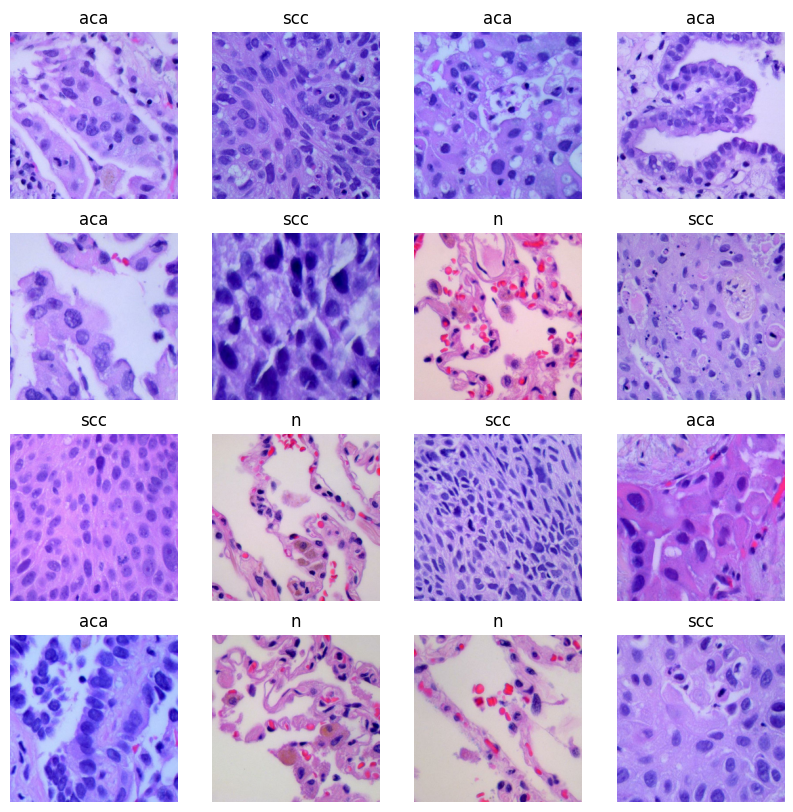

In [ ]:
def plot_16_images(dataset):
    images, labels = dataset[0] # Get the first batch
    fig, axes = plt.subplots(4, 4, figsize=(10,10))
    for i in range(4):
        for j in range(4):
            idx = i * 4 + j
            axes[i,j].imshow(images[idx])
            axes[i,j].axis('off')
            axes[i,j].set_title(classes[np.argmax(labels[idx])])
    plt.show()

plot_16_images(npdataset)

Describe, in your opinion, how adenocarcinoma cells (aca), normal cells (n), and squamous cell carcinoma cells (scc) can be recognized.

**Answer:**

Normals are more pink have more wired structures more part unfilled more red point

scc are more violet and are filled.

aca is more violet but are less filled than scc

We have created the training dataset, but the validation and test datasets also need to be created. Write a function `getDataset` that takes the string "train", "val", or "test" as input and returns the corresponding dataset. The calls to this function are given below:

In [ ]:
def getDataset(dataset_name):
  mydataset=tf.keras.preprocessing.image_dataset_from_directory(
    directory="dataset/"+dataset_name, # We fetch images from dataset/train
    class_names=classes, # Specify the 3 possible class names
    labels='inferred', # Classes are inferred from the subfolder names
    label_mode='categorical', # Specifies that classes should be OneHotEncoded
    image_size=(256,256),  # Specify the size of processed images. Processing them at full 768x768 resolution is unnecessary
    batch_size=100,  # Data will be organized into batches of 100
    shuffle=True) # Shuffle data before batching

  mydataset = mydataset.map(lambda images, labels: ( layers.Rescaling(1./255)(images), labels))
  # By default, image values range from 0 to 255. Divide by 255 to get values between 0 and 1
  # Several details to understand in this command:
  # map applies a function to all dataset elements. The argument of map must be a function
  # The dataset consists of both images and labels, so the input AND output of the argument function for map must be images, labels
  # lambda allows creating a one-line function. This function takes as input images and labels: and returns ( layers.Rescaling(1./255)(images), labels)

  # The next two commands will reduce computation time.
  mydataset = mydataset.cache()  # After the first load, the dataset is kept in memory
  mydataset = mydataset.prefetch(buffer_size=tf.data.AUTOTUNE)
  return mydataset

train_dataset = getDataset('train')
val_dataset = getDataset('val')
test_dataset = getDataset('test')

Found 600 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Found 1500 files belonging to 3 classes.


**IV) Model Creation**

Here is the code for a basic convolutional model:
* An image input of size 100x100 3 colors
* 2 convolutional layers with respective depths of 16 and 32, a kernel size of 3x3, ReLU activation, and MaxPooling of size (2,2) after each.
* 1 Flatten layer to flatten the output
* 1 Dense layer with 32 neurons and ReLU activation
* 1 Dense output layer for binary classification

In [ ]:
# Build your CNN model
def create_model():
  I = layers.Input(batch_shape=(None, 100, 100, 3)) # Input image size

  L1 = layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu')(I)
  L1 = layers.MaxPooling2D(pool_size=(2, 2))(L1) # Note that the output of the previous layer is passed as input to the next layer.

  L2 = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(L1)
  L2 = layers.MaxPooling2D(pool_size=(2, 2))(L2)

  Flat = layers.Flatten()(L2)

  D1 = layers.Dense(32, activation='relu')(Flat)

  output = layers.Dense(1, activation="sigmoid")(D1)
  return tf.keras.Model(I, output)

model = create_model()

model.summary()

Modify the previous model so that:
* The input size correspond to our datasets
*  **3 convolutional layers with respective filter counts of 32, 64, and 128**, a kernel size of 3x3, ReLU activation, and MaxPooling of size (2,2) after each.
*  1 Flatten layer to flatten the output
*  1 Dense layer with **128** neurons and ReLU activation
*  The output layer has the right number of neurons and the right activation function for our kind of problem (multi-class classification)

In [ ]:
# Build your CNN model
def create_model():
  I = layers.Input(batch_shape=(None, 256, 256, 3)) # Input image size

  L1 = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(I)
  L1 = layers.MaxPooling2D(pool_size=(2, 2))(L1) # Note that the output of the previous layer is passed as input to the next layer.

  L2 = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu')(L1)
  L2 = layers.MaxPooling2D(pool_size=(2, 2))(L2)

  L3 = layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu')(L2)
  L3 = layers.MaxPooling2D(pool_size=(2, 2))(L3)


  Flat = layers.Flatten()(L3)

  D1 = layers.Dense(128, activation='relu')(Flat)

  output = layers.Dense(3, activation="softmax")(D1)
  return tf.keras.Model(I, output)

model = create_model()

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,363 (56.61 MB)

 Trainable params: 14,839,363 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

For the first convolutional layer, you see that there are 896 trainable parameters. What do they correspond to?




**Answer:**

One filter have 3x3 (kernel size)x 3(input channel) weights + 1 bias

We have 32 filters so 32 x (3 x 3 x 3+1)=896

Using inspiration from the previous lab, add the commands to compile the model with a loss function `categorical_crossentropy` (since there are 3 one-hot encoded classes), an Adam optimizer with learning_rate 1.e-3, and the `Accuracy` metric.

Train the model for 50 epochs and add a checkpoint to save the best successive models in a folder `Model0` (filepath="Model0/best...").

The `model.fit` function accepts dataset objects as arguments. You can thus write:

model.fit(train_dataset, validation_data=val_dataset) instead of model.fit(X_train, Y_train, validation_data=(X_val, Y_val)) as in the previous lab.

In [ ]:
callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath="model0/best-{epoch:05d}-{val_loss:.4f}.keras", save_best_only=True, verbose=1)]
model = create_model()
model.compile(tf.optimizers.Adam(learning_rate=1e-3),
              "categorical_crossentropy",
              metrics=["accuracy"])
history = model.fit(train_dataset,
          epochs=50,
          validation_data=val_dataset,
          callbacks=callbacks)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.3139 - loss: 3.3666
Epoch 1: val_loss improved from inf to 0.82201, saving model to model0/best-00001-0.8220.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 601ms/step - accuracy: 0.3212 - loss: 3.2922 - val_accuracy: 0.6500 - val_loss: 0.8220
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6312 - loss: 0.8905
Epoch 2: val_loss did not improve from 0.82201
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.6192 - loss: 0.9179 - val_accuracy: 0.3933 - val_loss: 1.3483
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4985 - loss: 1.0045
Epoch 3: val_loss improved from 0.82201 to 0.54547, saving model to model0/best-00003-0.5455.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step - accuracy: 0.5025 - loss: 0.9853 - val_accuracy: 0.6533 - val_loss: 0.5455
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6490 - loss: 0.5593
Epoch 4: val_loss improved from 0.54547 to 0.52532, saving model to model0/bes

Note the best loss obtained and the associated accuracy on the validation data:

**Answer:** best val loss 0.3150 at epoch 17. val accuracy 0.8733

At iteration 50, compare the loss/accuracy with the previous answer and compare the loss/accuracy between the training data and validation data. Compare them to the best iteration results. What phenomena are observed?

**Answer:** at iteration 50 val loss is higher (0.9751) whereas the train loss is lower 3.4713e-04 vs 0.3244. So we can say there is a very high overfitting at iteration 50

To limit this phenomenon, we will add dropout layers after each convolutional layer (probability 0.5) and after the first Dense layer (P=0.5).

Preferably, dropout should be added before maxpooling.

Ex.

```
  L1 = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(I)
  L1 = layers.Dropout(0.3)(L1) #Here P=0.3
  L1 = layers.MaxPooling2D(pool_size=(2, 2))(L1)
```

Name this model `model1`.

In [ ]:
# Build your CNN model
def create_model():
  I = layers.Input(batch_shape=(None, 256, 256, 3)) # Input image size

  L1 = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(I)
  L1 = layers.Dropout(0.5)(L1) #Here P=0.3
  L1 = layers.MaxPooling2D(pool_size=(2, 2))(L1) # Note that the output of the previous layer is passed as input to the next layer.

  L2 = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu')(L1)
  L2 = layers.Dropout(0.5)(L2) #Here P=0.3
  L2 = layers.MaxPooling2D(pool_size=(2, 2))(L2)

  L3 = layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu')(L2)
  L3 = layers.Dropout(0.5)(L3) #Here P=0.3
  L3 = layers.MaxPooling2D(pool_size=(2, 2))(L3)


  Flat = layers.Flatten()(L3)

  D1 = layers.Dense(128, activation='relu')(Flat)
  D1 = layers.Dropout(0.5)(D1) #Here P=0.3

  output = layers.Dense(3, activation="softmax")(D1)
  return tf.keras.Model(I, output)



Train this new model for 80 epochs and store the results in the `Model1` folder.

In [ ]:

callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath="model1/best-{epoch:05d}-{val_loss:.4f}.keras", save_best_only=True, verbose=1)]
model = create_model()
model.compile(tf.optimizers.Adam(learning_rate=1e-3),
              "categorical_crossentropy",
              metrics=["accuracy"])
history = model.fit(train_dataset,
          epochs=80,
          validation_data=val_dataset,
          callbacks=callbacks)

Epoch 1/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.3795 - loss: 17.7841
Epoch 1: val_loss improved from inf to 1.03218, saving model to model1/best-00001-1.0322.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 441ms/step - accuracy: 0.3798 - loss: 17.4516 - val_accuracy: 0.3333 - val_loss: 1.0322
Epoch 2/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.4863 - loss: 1.2506
Epoch 2: val_loss improved from 1.03218 to 0.80664, saving model to model1/best-00002-0.8066.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.4930 - loss: 1.2122 - val_accuracy: 0.6500 - val_loss: 0.8066
Epoch 3/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.6695 - loss: 0.6378
Epoch 3: val_loss improved from 0.80664 to 0.67845, saving model to model1/best-00003-0.6784.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.6703 - loss: 0.6462 - val_accuracy: 0.6833 - val_loss: 0.6784
Epoch 4/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7374 - loss: 0.5157
Epoch 4: val_loss did no

Note the best loss obtained and the associated accuracy on the validation data:

**Answer:** Best model is  at iteration 55 val loss 0.3754  accuracy is 0.85

The performance on the validation data is expected to slightly improve, but due to randomness, this may not always be very evident. You may also notice that at iteration 50, there is less overfitting, but it is still very present.

---
To improve the model, we will apply data augmentation to the training data.
We will apply a random rotation to each image, varying at every epoch, and every second time, we will use the symmetrical version of the image.
Modify the `getDataset` function to add the following lines:

```
    data_augmentation = tf.keras.Sequential([
      layers.RandomRotation((-0.5, 0.5)),
      layers.RandomFlip()])
    mydataset = mydataset.map(lambda x, y: ( data_augmentation(x), y))
```
These lines should be added between `.cache()` and `.prefetch()`.

These commands should only be applied to the training data. Add an `if` condition for this.


In [ ]:
def getDataset(dataset_name):
  mydataset=tf.keras.preprocessing.image_dataset_from_directory(
    directory="dataset/"+dataset_name, # We fetch images from dataset/train
    class_names=classes, # Specify the 3 possible class names
    labels='inferred', # Classes are inferred from the subfolder names
    label_mode='categorical', # Specifies that classes should be OneHotEncoded
    image_size=(256,256),  # Specify the size of processed images. Processing them at full 768x768 resolution is unnecessary
    batch_size=100,  # Data will be organized into batches of 100
    shuffle=True) # Shuffle data before batching

  mydataset = mydataset.map(lambda images, labels: ( layers.Rescaling(1./255)(images), labels))
  # By default, image values range from 0 to 255. Divide by 255 to get values between 0 and 1
  # Several details to understand in this command:
  # map applies a function to all dataset elements. The argument of map must be a function
  # The dataset consists of both images and labels, so the input AND output of the argument function for map must be images, labels
  # lambda allows creating a one-line function. This function takes as input images and labels: and returns ( layers.Rescaling(1./255)(images), labels)

  # The next two commands will reduce computation time.
  mydataset = mydataset.cache()  # After the first load, the dataset is kept in memory
  if dataset_name == 'train':
    data_augmentation = tf.keras.Sequential([
      layers.RandomRotation((-0.5, 0.5)),
      layers.RandomFlip()])
    mydataset = mydataset.map(lambda x, y: ( data_augmentation(x), y))
  mydataset = mydataset.prefetch(buffer_size=tf.data.AUTOTUNE)
  return mydataset

train_dataset = getDataset('train')
val_dataset = getDataset('val')
test_dataset = getDataset('test')

Found 600 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Found 1500 files belonging to 3 classes.


Recreate the model (named `model2`) with a dropout rate of 0.3 on all layers (to accelerate convergence), recompile it, and retrain it for 100 epochs. Store the models in the folder `Model2`.


In [ ]:
# Build your CNN model
def create_model():
  I = layers.Input(batch_shape=(None, 256, 256, 3)) # Input image size

  L1 = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(I)
  L1 = layers.Dropout(0.5)(L1) #Here P=0.3
  L1 = layers.MaxPooling2D(pool_size=(2, 2))(L1) # Note that the output of the previous layer is passed as input to the next layer.

  L2 = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu')(L1)
  L2 = layers.Dropout(0.5)(L2) #Here P=0.3
  L2 = layers.MaxPooling2D(pool_size=(2, 2))(L2)

  L3 = layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu')(L2)
  L3 = layers.Dropout(0.5)(L3) #Here P=0.3
  L3 = layers.MaxPooling2D(pool_size=(2, 2))(L3)


  Flat = layers.Flatten()(L3)

  D1 = layers.Dense(128, activation='relu')(Flat)
  D1 = layers.Dropout(0.5)(D1) #Here P=0.3

  output = layers.Dense(3, activation="softmax")(D1)
  return tf.keras.Model(I, output)


callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath="model2/best-{epoch:05d}-{val_loss:.4f}.keras", save_best_only=True, verbose=1)]
model = create_model()
model.compile(tf.optimizers.Adam(learning_rate=1e-3),
              "categorical_crossentropy",
              metrics=["accuracy"])
history = model.fit(train_dataset,
          epochs=100,
          validation_data=val_dataset,
          callbacks=callbacks)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.3721 - loss: 9.4572
Epoch 1: val_loss improved from inf to 0.90081, saving model to model2/best-00001-0.9008.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3832 - loss: 9.2829 - val_accuracy: 0.6367 - val_loss: 0.9008
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.6490 - loss: 0.7301
Epoch 2: val_loss improved from 0.90081 to 0.86283, saving model to model2/best-00002-0.8628.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6532 - loss: 0.7181 - val_accuracy: 0.6500 - val_loss: 0.8628
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.6534 - loss: 0.6259
Epoch 3: val_loss did not improve from 0.86283
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 953ms/step - accuracy: 0.6534 - loss: 0.6261 - val_accuracy: 0.6933 - val_loss: 0.9452
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.7156 - loss: 0.5577
Epoch 4: val_loss improved from 0.86283 to 0.76797, saving model to model2/best

Note the best loss obtained and the associated accuracy on the validation data:

**Answer:** val_accuracy: 0.8933 - val_loss: 0.3113 at iteration 86

**V) XAI (Explainable AI)**

**Q.** Using Artificial Intelligence as an assistant, implement Grad-CAM on your trained model and visualize the results for 30 images from the validation dataset. The visualization should consist of 3 columns: the original image, the heatmap of the predicted class, and the heatmap of the ground truth label class. Above each image, display the label and the prediction. Use GradientTape and do not use any libraries other than OpenCV for image processing

In [ ]:
import cv2
model = tf.keras.models.load_model('model2/best-00086-0.3113.keras')
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last conv layer
    # and the output predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute the gradient of the output neuron for the class with regard to the output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Global average pooling of the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weighted sum of feature maps
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and normalization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def plot_gradcam_30(dataset, model):
    last_conv_layer_name = get_last_conv_layer(model)

    # Get a batch of images
    for images, labels in dataset.take(1):
        images = images[:30]
        labels = labels[:30]
        break

    fig, axes = plt.subplots(30, 3, figsize=(10, 90))

    for i in range(30):
        img = images[i]
        label_idx = np.argmax(labels[i])
        img_array = tf.expand_dims(img, axis=0)

        preds = model.predict(img_array, verbose=0)
        pred_idx = np.argmax(preds[0])

        # Heatmap for prediction
        heatmap_pred = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_idx)
        heatmap_pred = cv2.resize(heatmap_pred, (img.shape[1], img.shape[0]))
        heatmap_pred = np.uint8(255 * heatmap_pred)
        heatmap_pred = cv2.applyColorMap(heatmap_pred, cv2.COLORMAP_JET)

        # Heatmap for ground truth
        heatmap_true = make_gradcam_heatmap(img_array, model, last_conv_layer_name, label_idx)
        heatmap_true = cv2.resize(heatmap_true, (img.shape[1], img.shape[0]))
        heatmap_true = np.uint8(255 * heatmap_true)
        heatmap_true = cv2.applyColorMap(heatmap_true, cv2.COLORMAP_JET)

        # Original Image (0-255)
        img_uint8 = np.uint8(255 * img.numpy())

        # Superimpose (convert heatmap BGR to RGB first)
        heatmap_pred = cv2.cvtColor(heatmap_pred, cv2.COLOR_BGR2RGB)
        heatmap_true = cv2.cvtColor(heatmap_true, cv2.COLOR_BGR2RGB)

        superimposed_pred = cv2.addWeighted(img_uint8, 0.6, heatmap_pred, 0.4, 0)
        superimposed_true = cv2.addWeighted(img_uint8, 0.6, heatmap_true, 0.4, 0)

        # Column 1: Original + Label/Pred
        axes[i, 0].imshow(img.numpy())
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f"Label: {classes[label_idx]}\nPred: {classes[pred_idx]}")

        # Column 2: Pred Heatmap
        axes[i, 1].imshow(superimposed_pred)
        axes[i, 1].axis('off')
        axes[i, 1].set_title(f"GradCAM (Pred: {classes[pred_idx]})")

        # Column 3: True Heatmap
        axes[i, 2].imshow(superimposed_true)
        axes[i, 2].axis('off')
        axes[i, 2].set_title(f"GradCAM (True: {classes[label_idx]})")

    plt.tight_layout()
    plt.show()

plot_gradcam_30(val_dataset, model)

Output hidden; open in https://colab.research.google.com to view.


**VI) Transfer Learning**

We will use a pre-trained network, VGG19, to perform feature extraction and add layers at the output of VGG19 to perform our classification.

VGG19 is trained on the ImageNet dataset, which accepts input images of size 224x224. Modify the dataset creation commands to use this size.

In [ ]:
def getDataset(dataset_name):
  mydataset=tf.keras.preprocessing.image_dataset_from_directory(
    directory="dataset/"+dataset_name, # We fetch images from dataset/train
    class_names=classes, # Specify the 3 possible class names
    labels='inferred', # Classes are inferred from the subfolder names
    label_mode='categorical', # Specifies that classes should be OneHotEncoded
    image_size=(224,224),  # Specify the size of processed images. Processing them at full 768x768 resolution is unnecessary
    batch_size=100,  # Data will be organized into batches of 100
    shuffle=True) # Shuffle data before batching

  mydataset = mydataset.map(lambda images, labels: ( layers.Rescaling(1./255)(images), labels))
  # By default, image values range from 0 to 255. Divide by 255 to get values between 0 and 1
  # Several details to understand in this command:
  # map applies a function to all dataset elements. The argument of map must be a function
  # The dataset consists of both images and labels, so the input AND output of the argument function for map must be images, labels
  # lambda allows creating a one-line function. This function takes as input images and labels: and returns ( layers.Rescaling(1./255)(images), labels)

  # The next two commands will reduce computation time.
  mydataset = mydataset.cache()  # After the first load, the dataset is kept in memory
  if dataset_name == 'train':
    data_augmentation = tf.keras.Sequential([
      layers.RandomRotation((-0.5, 0.5)),
      layers.RandomFlip()])
    mydataset = mydataset.map(lambda x, y: ( data_augmentation(x), y))
  mydataset = mydataset.prefetch(buffer_size=tf.data.AUTOTUNE)
  return mydataset

train_dataset = getDataset('train')
val_dataset = getDataset('val')
test_dataset = getDataset('test')

Here is the code to integrate the VGG19 layers into the model.
Add, at the indicated location:

*   A Dense layer with 128 neurons and ReLU activation, followed by a dropout with p=0.2
*   A Dense layer with 64 neurons and ReLU activation, followed by a dropout with p=0.2
*   The output layer as before


In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19

vgg = VGG19(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

# The VGG base is already trained, and its layers should not be modified.
for layer in vgg.layers:
    layer.trainable = False

flatten = layers.Flatten()(vgg.layers[-1].output)
D1=layers.Dense(128, activation='relu')(flatten)
D1=layers.Dropout(0.2)(D1)
D2=layers.Dense(64, activation='relu')(D1)
D2=layers.Dropout(0.2)(D2)
output=layers.Dense(3, activation='softmax')(D2)

model = tf.keras.Model(inputs=vgg.input, outputs=output)

model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_129"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             

 Total params: 23,244,227 (88.67 MB)

 Trainable params: 3,219,843 (12.28 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

Train the model for 100 epochs and save the best weights in the `Model3` folder.

In [ ]:

callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath="model3/best-{epoch:05d}-{val_loss:.4f}.keras", save_best_only=True, verbose=1)]
# model = create_model() ERROR
model.compile(tf.optimizers.Adam(learning_rate=1e-3),
              "categorical_crossentropy",
              metrics=["accuracy"])
history = model.fit(train_dataset,
          epochs=100,
          validation_data=val_dataset,
          callbacks=callbacks)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.3393 - loss: 20.1602
Epoch 1: val_loss improved from inf to 1.08252, saving model to model3/best-00001-1.0825.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3403 - loss: 19.7872 - val_accuracy: 0.3333 - val_loss: 1.0825
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.4009 - loss: 1.0915
Epoch 2: val_loss improved from 1.08252 to 1.04098, saving model to model3/best-00002-1.0410.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4005 - loss: 1.0893 - val_accuracy: 0.6600 - val_loss: 1.0410
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.5720 - loss: 0.8402
Epoch 3: val_loss improved from 1.04098 to 0.86948, saving model to model3/best-00003-0.8695.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5736 - loss: 0.8302 - val_accuracy: 0.6500 - val_loss: 0.8695
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.6431 - loss: 0.6128
Epoch 4: val_loss improved f

Note the best loss obtained and the associated accuracy on the validation data. Is it better than the previous models?

**Answer:** Best lost is 0.3685 strangely not better than the first model (usually it gives ~0.23)

val_accuracy: 0.8900

Using the code from the previous lab, display the accuracy and loss evolution curves.

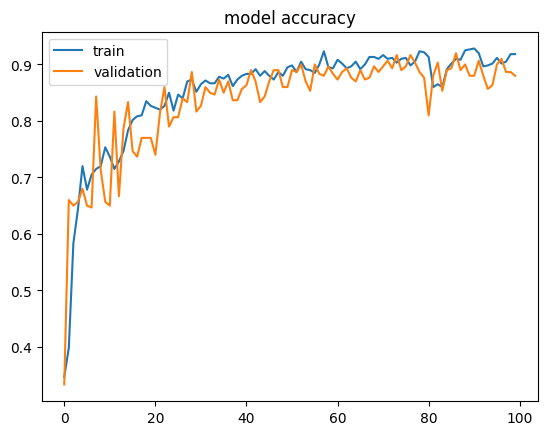

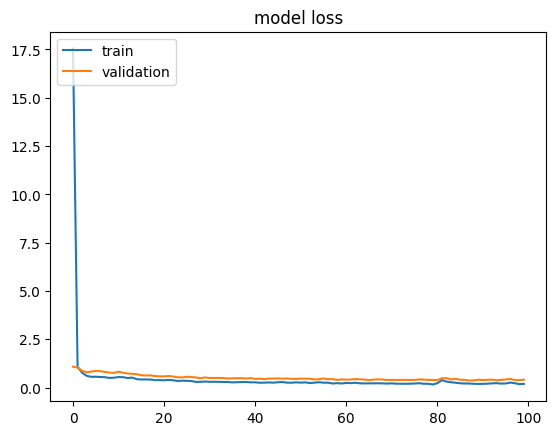

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy']) # The variable `history` is the output of model.fit
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'validation'], loc='upper left')
plt.title('model accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'validation'], loc='upper left')
plt.title('model loss')
plt.show()

At the beginning, the performance on the training data is worse than on the validation data. This is due to dropout, which adds noise to the training data.

The performance on the training data keeps improving, but it stagnates on the validation data. Nevertheless, the record is still broken towards the end, so there is no overfitting yet. However, there is an evaluation bias because, in the end, the performance on the training data is better than on the validation data.

Load the best model you obtained in this lab and evaluate its performance on the test dataset. The `model.evaluate` command accepts a dataset as input.

In [ ]:
model = tf.keras.models.load_model('/content/model3/best-00088-0.3685.keras')
model.evaluate(test_dataset)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9138 - loss: 0.3595


[0.36575472354888916, 0.9139999747276306]

In general, due to evaluation bias, the performance on the test data is worse than on the validation data, but randomness may result in the opposite here. We remind also that due to the huge error of the dataset's author, there is no true test dataset on unseen data.

The following commands display the confusion matrix and show the errors made by the model.

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


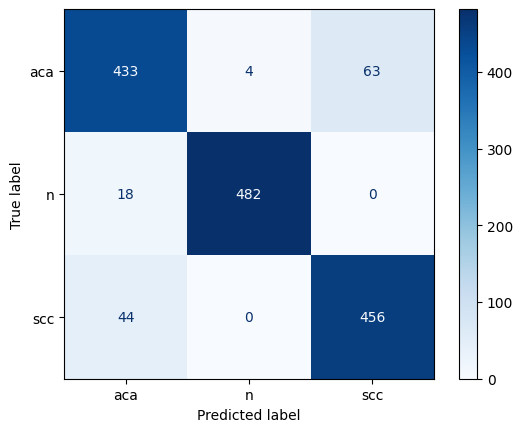

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

ypred = model.predict(test_dataset)
ypred = np.argmax(ypred, axis=1)

A = list(test_dataset.unbatch().as_numpy_iterator())
ytest = np.concatenate([A[i][1][None, :] for i in range(len(A))])
ytest = np.argmax(ytest, axis=1)

cm = confusion_matrix(ytest, ypred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(cmap=plt.cm.Blues)
plt.show()

What conclusions can you draw about the difficulties of this image classification problem from this table? Does it match the challenges you encountered on visual classification?

**Answer:**

Normal vs scc no error this was quit obvious. Normal vs aca very few error. aca vs scc a few errors as we have seen visually this is the less obvious cases